# DSC 530 - Data Exploration and Analysis
## Week 11
### Manoj K Kola

### DSC 530 Final Project – Exploratory Data Analysis of Netflix Content

This notebook presents a comprehensive **Exploratory Data Analysis (EDA)** of the **Netflix Movies and TV Shows** dataset sourced from **Kaggle**. The goal is to uncover patterns, trends, and relationships within the dataset using statistical techniques, visualizations, and predictive modeling.

The analysis follows the structured guidelines provided in the project brief, including:

- Data cleaning and preparation
- Univariate and bivariate analysis
- Hypothesis testing
- Regression and classification modeling
- Clustering and dimensionality reduction

Each section is clearly labeled and documented to ensure reproducibility and transparency. The insights derived from this analysis will support the narrative in Part 2, highlighting key findings and actionable recommendations.

### Dataset Loading

#### Overview

This code automates the steps required to download the ***Netflix*** dataset from ***Kaggle*** and move it into a designated project folder. It ensures that all essential libraries are loaded, the dataset is retrieved successfully, and the downloaded files are organized properly for further analysis.

#### Key Steps

 - **Library Imports:** The script begins by importing ***all necessary libraries*** for handling data, visualizations, file movement, and file paths.
 - **Dataset Download:** It retrieves the latest cleaned Netflix dataset using `kagglehub.dataset_download()`, ensuring you always work with the most updated version.
 - **Download Path Output:** The code prints the ***path where the dataset was saved***, helping you confirm the download location.
 - **Destination Setup:** A ***destination folder path*** is defined to specify where the dataset should be placed within your project environment.
 - **File Transfer:** The script loops through each downloaded file and ***moves it to the destination directory***, keeping everything neatly organized and ready for use.

In [81]:
# Imports and dataset load
import os                     # For interacting with the operating system
import pandas as pd            # For data manipulation and analysis
import numpy as np             # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns          # For advanced data visualization
from pathlib import Path       # For handling file paths
import shutil                  # For moving files

# Download latest version of the Netflix dataset from Kaggle
path = kagglehub.dataset_download("hqdataprofiler/cleaned-netflix-movies-and-tv-shows")

# Print the path where dataset files are stored
print("Path to dataset files:", path)

# Define destination folder
destination = Path(r"C:\Users\manoj\miniconda3\dsc530\envs\book_env\Hands-On-Data-Analysis-with-Pandas-2nd-edition-master")

# Move the downloaded dataset to the destination folder
for file in Path(path).glob('*'):   # Loop through all files in the downloaded folder
    shutil.move(str(file), destination)

print(f"All files moved to: {destination}")


Path to dataset files: C:\Users\manoj\.cache\kagglehub\datasets\hqdataprofiler\cleaned-netflix-movies-and-tv-shows\versions\1
All files moved to: C:\Users\manoj\miniconda3\dsc530\envs\book_env\Hands-On-Data-Analysis-with-Pandas-2nd-edition-master


#### Overview

This code loads the ***cleaned Netflix dataset*** from a CSV file and provides a quick preview of its contents. It ensures that the dataset is successfully imported into a pandas DataFrame and displays the first few records for verification.

#### Key Steps

 - **Loading the Dataset:** The script reads the CSV file `netflix_titles_CLEANED.csv` into a pandas DataFrame named `netflix`, making it ready for analysis.
 - **Previewing Data:** It shows the first five rows of the dataset using `netflix.head()`, giving a quick snapshot of the data structure and contents.
 - **Printing Records:** The first five records are printed to the console with a descriptive message, helping to ***verify that the dataset was loaded correctly.***

In [83]:
# Load the Netflix dataset from a CSV file
netflix = pd.read_csv("netflix_titles_CLEANED.csv") 

# Show the first 5 rows of the dataset
netflix.head()

# Print the first 5 records in the console
print("First 5 records:", netflix.head())


First 5 records:   show_id     type                  title        directors  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast      countries  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September

### Initial Inspection

#### Overview

This code ***inspects, summarizes, and cleans*** the Netflix dataset. It displays the dataset’s structure, handles missing or improperly formatted data, and ensures column names and date fields are standardized for further analysis.

#### Key Steps

 - **Display Column Names:** Prints all ***column names*** in the dataset if the `netflix` DataFrame exists.
 - **Dataset Information:** If the dataset exists, the script shows ***basic information*** including column names, data types, and missing values using `netflix.info()`.
 - **Summary Statistics:** Displays ***summary statistics*** for all columns using `netflix.describe(include='all').T`, giving an overview of numeric and categorical data.
 - **Clean Column Names:** Strips extra spaces from column names to ensure ***consistent and clean naming***.
 - **Fix Date Columns:** Attempts to convert year/date columns (`release_year, date_added, release_date, year`) into proper ***datetime format*** for easier analysis. Errors during conversion are safely ignored.
 - **Remove Duplicates:** Checks for and removes any ***duplicate rows***, printing the number of rows dropped to maintain dataset integrity.

In [84]:
# Show all column names in the dataset
print('Columns:', [] if 'netflix' not in globals() else list(netflix.columns))

# If the dataset 'netflix' exists, show info and summary statistics
if 'netflix' in globals():
    # Show basic information about the dataset 
    # (like column names, data types, and missing values)
    display(netflix.info())

    # Show summary statistics for all columns
    display(netflix.describe(include='all').T)

# Clean column names and fix date columns
if 'netflix' in globals():
    # Remove extra spaces from column names
    netflix.columns = [c.strip() for c in netflix.columns]
    
    # Try to convert year/date columns to proper datetime format
    for col in ['release_year','date_added','release_date','year']:
        if col in netflix.columns:
            try:
                netflix[col+'_dt'] = pd.to_datetime(netflix[col], errors='coerce')
            except Exception:
                pass

    # Remove duplicate rows, if any
    before = len(netflix)
    netflix = netflix.drop_duplicates()
    after = len(netflix)
    print(f'\nDropped {before-after} duplicate rows')


Columns: ['show_id', 'type', 'title', 'directors', 'cast', 'countries', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   directors     6173 non-null   object
 4   cast          7982 non-null   object
 5   countries     7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
directors,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
countries,7976,746,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1714,"January 1, 2020",110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Dropped 0 duplicate rows


#### Overview

This code checks for missing values in the Netflix dataset and provides both a summary and a visual representation. It helps identify which columns have incomplete data and allows you to quickly assess the overall data quality before analysis.

#### Key Steps

 - **Check Dataset Availability:** The code first ensures that the `netflix` ***dataset exists in memory*** before performing any operations.
 - **Count Missing Values:** It calculates the number of missing entries in each column using `isnull().sum()` and sorts them from the ***most missing to least missing***.
 - **Display Missing Data:** Only columns that have ***missing values*** are displayed, making it easier to focus on incomplete data.
 - **Visualize Missing Values:** The script attempts to create a ***heatmap using Seaborn*** to visually represent missing data patterns across the dataset.
 - **Heatmap Customization:** The heatmap is sized, titled, and formatted neatly using ***Matplotlib functions***. It is also saved as an image file called `missing_heatmap.png`.
 - **Error Handling:** If the heatmap creation fails, the code prints a ***clear error message*** so you know what went wrong without stopping the script.

directors        2634
countries         831
cast              825
date_added         10
date_added_dt      10
rating              4
duration            3
dtype: int64

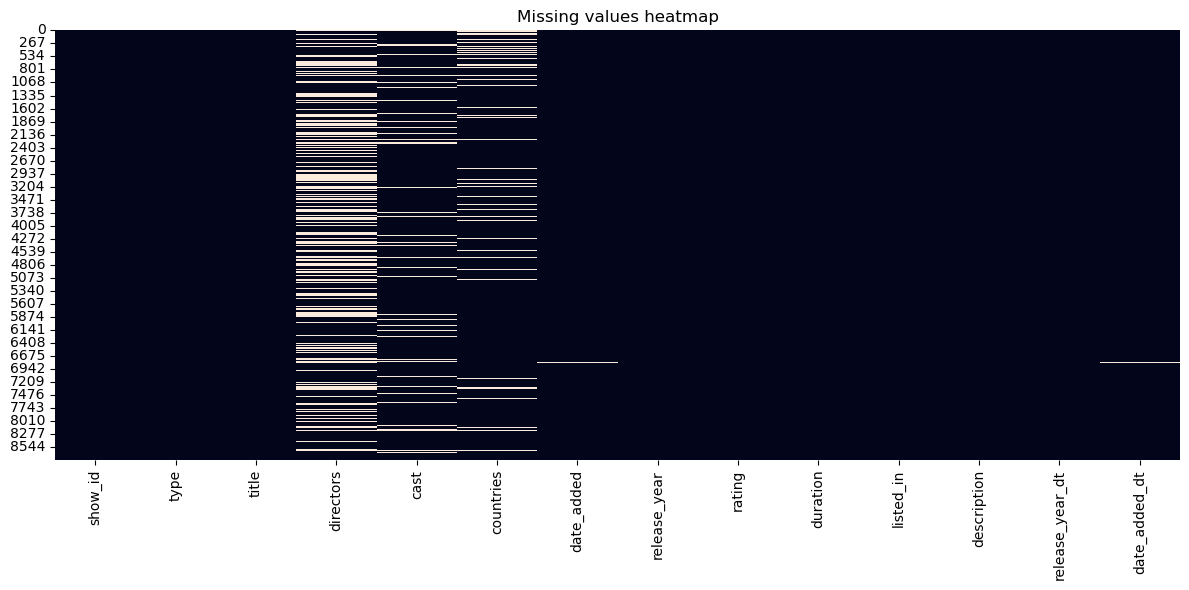

In [71]:
# Check for missing values in the dataset
if 'netflix' in globals():
    # Count missing values in each column and sort from most to least
    missing = netflix.isnull().sum().sort_values(ascending=False)
    # Show only the columns that have missing values
    display(missing[missing > 0])

    # Try to create a heatmap to visualize missing data
    try:
        import seaborn as sns
        plt.figure(figsize=(12,6))
        sns.heatmap(netflix.isnull(), cbar=False)
        plt.title('Missing values heatmap')
        plt.tight_layout()
        plt.savefig('missing_heatmap.png')  # Save the chart as an image
        plt.show()
    except Exception as e:
        # If something goes wrong, print the error message
        print('Could not make missing heatmap:', e)


#### Overview

This code performs essential data cleaning and feature-engineering steps on the `netflix` dataset. It handles missing values, removes incomplete records, converts date fields into usable formats, and ***creates new time-based columns*** to support further analysis.

#### Key Steps

 - **Handling Missing Ratings:** The script fills missing values in the *rating* column with ***'Unknown'***, ensuring the dataset remains consistent without losing rows unnecessarily.
 - **Dropping Incomplete Records:** Rows with missing values in the *title* or *type* columns are removed, keeping only entries with essential identifying information.
 - **Date Conversion:** The ***'date_added'*** column is converted into a proper datetime format, making it easier to extract and analyze date-related information.
 - **Extracting Year Added:** A new column, ***'year_added'***, is created by pulling the year from the converted *date_added* field.
 - **Extracting Month Added:** Another new column, ***'month_added'***, is created by extracting the month value from the *date_added* column to enable monthly trend analysis.

In [88]:
# Fill missing values in 'rating' column with 'Unknown'
netflix.fillna({'rating':'Unknown'}, inplace=True)

# Drop rows where 'title' or 'type' is missing
netflix.dropna(subset=['title', 'type'], inplace=True)

# Convert 'date_added' column to datetime format
netflix['date_added'] = pd.to_datetime(netflix['date_added'])

# Create new column 'year_added' from 'date_added'
netflix['year_added'] = netflix['date_added'].dt.year

# Create new column 'month_added' from 'date_added'
netflix['month_added'] = netflix['date_added'].dt.month


### Univariate Analysis

**Univariate Analysis** is a type of data analysis that focuses on exploring and understanding a ***single variable at a time***. It helps us understand how that variable behaves by examining its distribution, central values (such as mean or median), spread, and common patterns.

#### Overview

This code performs univariate analysis on the `Netflix` dataset by examining each column independently. It identifies numeric and categorical variables, generates summary statistics, and creates visual charts to better understand the distribution of data within key columns.

#### Key Steps

 - **Column Identification:** The script starts by separating ***numeric and categorical columns*** using their data types and prints both lists for quick reference.
 - **Summary Statistics:** It displays ***descriptive statistics*** for all numeric columns, giving insights into measures such as mean, standard deviation, and quartiles.
 - **Numeric Column Visuals:** For the first six numeric columns, the script generates ***histograms with KDE curves*** to show how each variable is distributed. Each plot is saved as an image and displayed on screen.
 - **Categorical Column Visuals:** If at least one categorical column exists, the script selects the first one and plots a ***bar chart of the top 20 most frequent values***, helping visualize the category distribution. The bar chart is also saved as an image for documentation.

Numeric cols: ['release_year', 'year_added', 'month_added']
Categorical cols: ['show_id', 'type', 'title', 'directors', 'cast', 'countries', 'rating', 'duration', 'listed_in', 'description']


,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
year_added,8797.0,2018.871888,1.574243,2008.0,2018.0,2019.0,2020.0,2021.0
month_added,8797.0,6.654996,3.436554,1.0,4.0,7.0,10.0,12.0


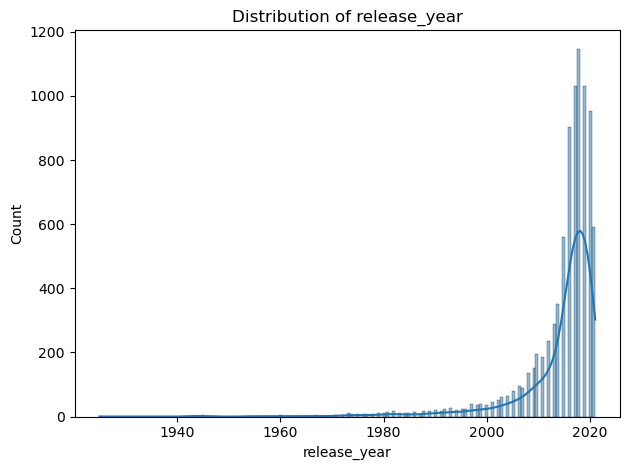

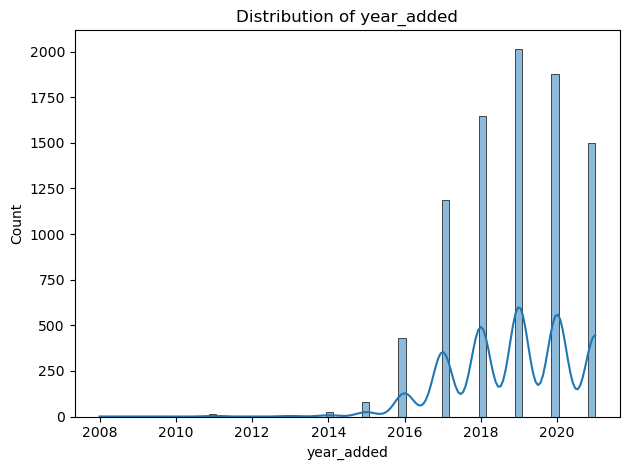

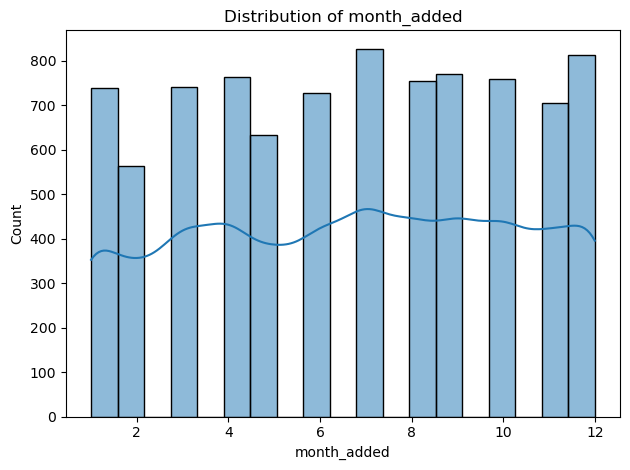

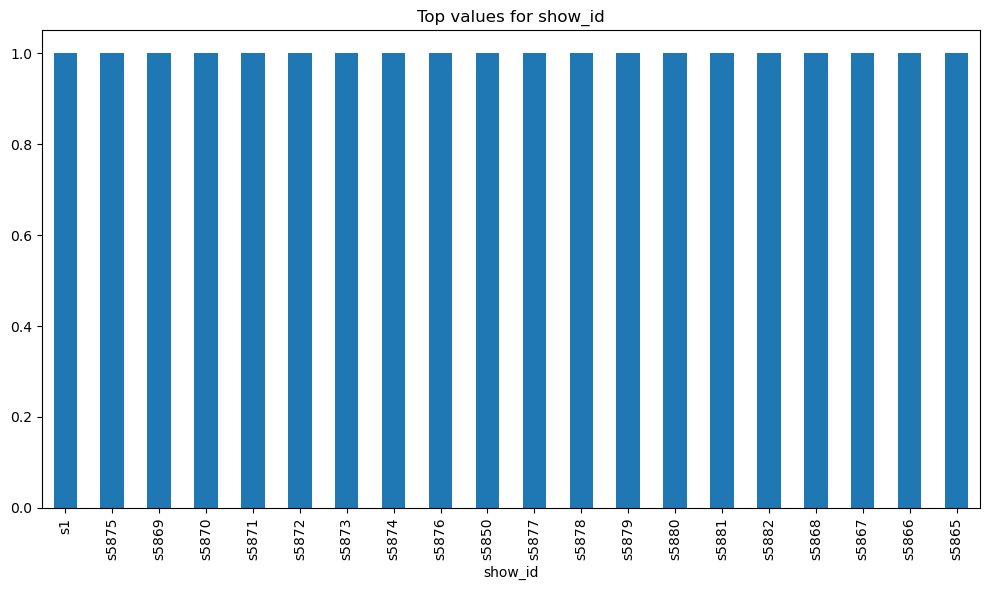

In [89]:
# Univariate analysis: analyze individual columns in the dataset
if 'netflix' in globals():
    # Separate numeric and categorical columns
    numeric = netflix.select_dtypes(include=[np.number]).columns.tolist()
    categorical = netflix.select_dtypes(include=['object','category']).columns.tolist()
    print('Numeric cols:', numeric)       # Print list of numeric columns
    print('Categorical cols:', categorical)  # Print list of categorical columns

    # Show summary statistics for numeric columns
    display(netflix[numeric].describe().T)

    # Plot histograms for the first 6 numeric columns
    for col in (numeric[:6]):
        plt.figure()
        sns.histplot(netflix[col].dropna(), kde=True)  # Plot histogram with density curve
        plt.title(f'Distribution of {col}')           # Add title to plot
        fname = f'univar_hist_{col}.png'             # Filename to save the plot
        plt.tight_layout()
        plt.savefig(fname)                            # Save figure to file
        plt.show()                                    # Display plot
        plt.close()                                   # Close figure to free memory

    # Plot bar chart for the first categorical column
    if len(categorical)>0:
        topcat = categorical[0]
        plt.figure(figsize=(10,6))
        netflix[topcat].value_counts().head(20).plot(kind='bar')  # Plot top 20 category counts
        plt.title(f'Top values for {topcat}')                     # Add title
        plt.tight_layout()
        plt.savefig('top_category_counts.png')                    # Save figure
        plt.show()
        plt.close()                                               # Close figure


#### Overview

This code generates visualizations to understand the ***distribution of content types and release years*** in the `Netflix` dataset. It also computes descriptive statistics along with skewness and kurtosis to analyze the overall shape and spread of the data.

#### Key Steps

 - **Content Type Plot:** The script creates a bar chart using `sns.countplot()` to show how many entries belong to each content type (Movies, TV Shows, etc.) and saves the figure as an image for later use.
 - **Release Year Histogram:** It builds a histogram of ***release years*** with 30 bins to visualize how content production has varied over time, labeling axes and saving the plot as a PNG file.
 - **Descriptive Statistics:** The code uses `.describe()` to generate key statistical values such as count, mean, standard deviation, and quartiles for the release year column.
 - **Skewness & Kurtosis:** It calculates ***skewness and kurtosis*** to understand how the release year distribution deviates from normality in terms of symmetry and peak shape.

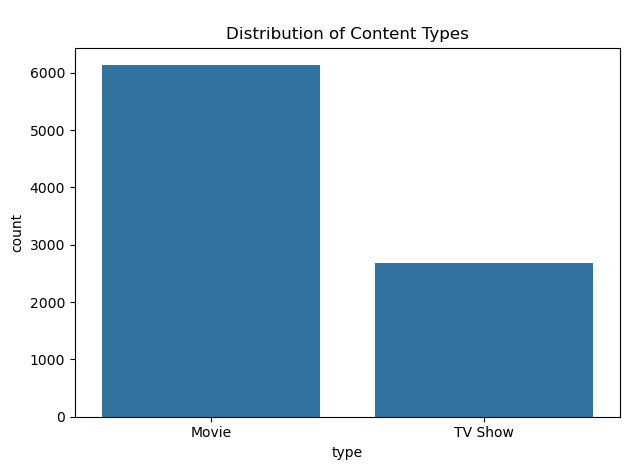

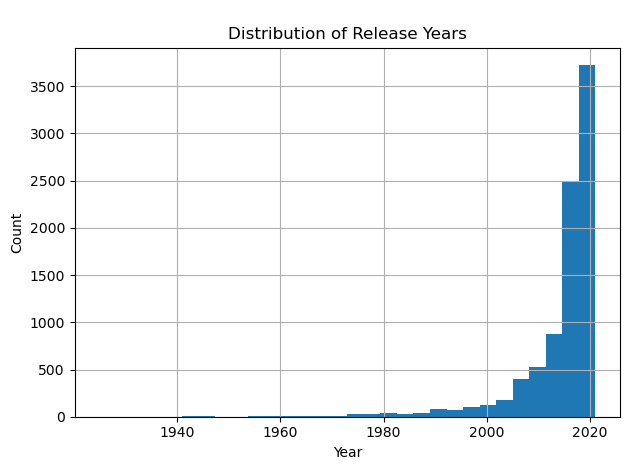

(-3.4465650403316013, 16.232225648417085)

In [90]:
# Plot the count of each content type (Movie, TV Show, etc.)
sns.countplot(data=netflix, x='type')
plt.title("\nDistribution of Content Types")  # Add title to the plot
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.savefig('Distribution_Content.png')  # Save the figure as a PNG file
plt.show()  # Display the plot
plt.close()  # Close the plot to free memory

# Plot histogram of release years
netflix['release_year'].hist(bins=30)  # Create histogram with 30 bins
plt.title("\nDistribution of Release Years")  # Add title
plt.xlabel("Year")  # Label x-axis
plt.ylabel("Count")  # Label y-axis
plt.tight_layout()  # Adjust layout
plt.savefig('Distribution_Release_Year.png')  # Save figure
plt.show()  # Display plot
plt.close()  # Close the plot

# Show descriptive statistics for release years
netflix['release_year'].describe()  # Count, mean, std, min, quartiles, max

# Calculate skewness and kurtosis for release years
netflix['release_year'].skew(), netflix['release_year'].kurt()  # Check data distribution shape


### Bivariate Analysis

**Bivariate Analysis** is a statistical method used to explore and understand the relationship between ***two variables simultaneously***. It helps determine whether the variables are related, how strong the relationship is, and what type of association exists (positive, negative, or none).

Common techniques include:

 - **Correlation analysis** (for numerical variables)
 - **Scatterplots** (to visualize relationships)
 - **Cross-tabulations** (for categorical variables)
 - **Boxplots** (comparing one numeric and one categorical variable)

In simple terms, ***bivariate analysis shows how one variable changes in relation to another***, helping identify patterns, trends, or dependencies between the two.

#### Overview

This code performs bivariate analysis on the `netflix` dataset by exploring relationships between numerical variables and visualizing these relationships using ***heatmaps, scatterplots, and boxplots***. It checks for necessary columns, computes correlations, and generates insightful visual outputs that help understand how different variables interact.

#### Key Steps

 - **Checking Dataset Availability:** The script first verifies that the `netflix` ***dataframe exists in the environment*** before running any analysis.
 - **Selecting Numeric Columns:** It identifies ***all numeric columns*** in the dataset to prepare for correlation analysis.
 - **Correlation Matrix:** If numeric columns are present, the code computes a ***correlation matrix*** and displays it using a heatmap with clear annotations.
 - **Heatmap Visualization:** A correlation heatmap is generated using ***Seaborn's*** `heatmap` ***function***, saved as an image, and displayed to help interpret variable relationships.
 - **Scatter Plot (Rating vs Duration):** If both `rating` and `duration` columns exist, the script creates a ***scatterplot showing the relationship*** between movie duration and rating, saving it for later use.
 - **Boxplot by Content Type:** A boxplot is generated to compare ***release years across different content types***, providing insights into trends between movies and TV shows.

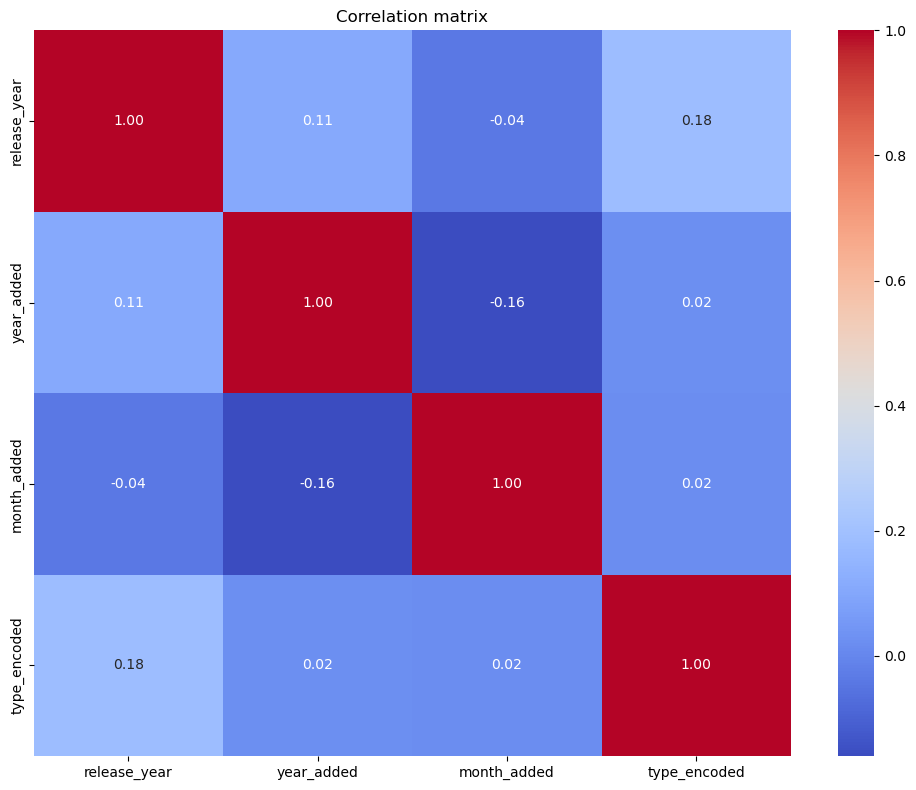

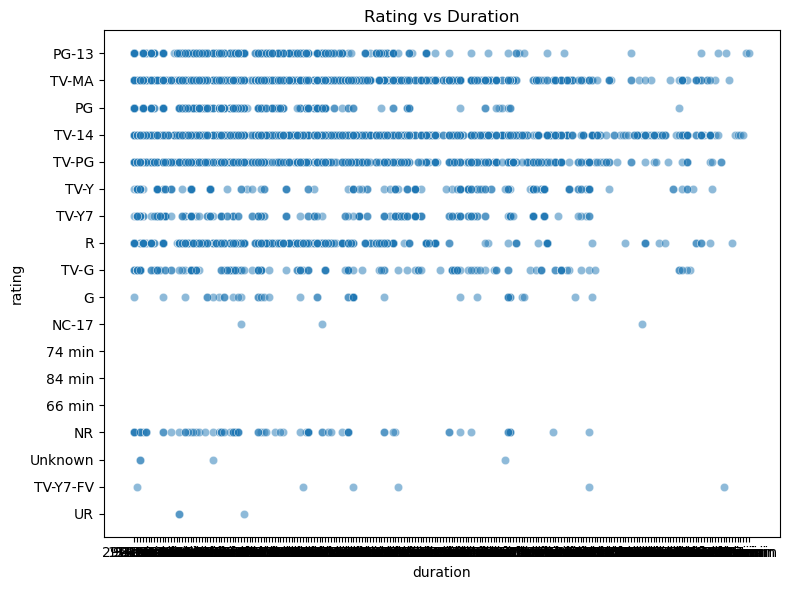

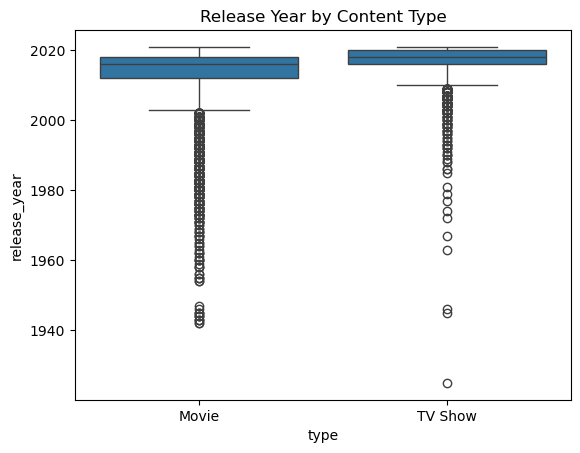

In [102]:
# Bivariate analysis: correlation and scatterplots
if 'netflix' in globals():
    # Select numeric columns for correlation analysis
    numeric = netflix.select_dtypes(include=[np.number]).columns.tolist()
    
    if len(numeric) >= 1:
        # Compute correlation matrix for numeric columns
        corr = netflix[numeric].corr()
        
        # Plot correlation heatmap
        plt.figure(figsize=(10,8))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
        plt.title('Correlation matrix')
        plt.tight_layout()
        plt.savefig('correlation_matrix.png')  # Save heatmap as image
        plt.show()
        plt.close()

    # Scatter plot example: rating vs runtime
    if 'rating' in netflix.columns and 'duration' in netflix.columns:
        plt.figure(figsize=(8,6))
        sns.scatterplot(data=netflix, x='duration', y='rating', alpha=0.5)
        plt.title('Rating vs Duration')
        plt.tight_layout()
        plt.savefig('rating_vs_duration.png')  # Save scatter plot as image
        plt.show()
        plt.close()

    # Boxplot: Compare release year by content type
    sns.boxplot(data=netflix, x='type', y='release_year')
    plt.title("Release Year by Content Type")
    plt.savefig('Release_year_Content_type.png')  # Save boxplot as image
    plt.show()
    plt.close()


### Hypothesis Testing

**Hypothesis Testing** is a statistical method used to ***check if a claim or assumption about a group or dataset is likely true or false***. It compares data against a statement (called a hypothesis) and uses evidence from the data to decide whether to accept or reject that statement.

#### Overview

This code performs a hypothesis test to compare whether there is a significant difference in release years between Movies and TV Shows in the Netflix dataset. It separates the data into two groups and applies a statistical test to evaluate if their average release years differ.

#### Key Steps

 - **Filtering the Data:** The script extracts ***release years for Movies and TV Shows** by filtering the `netflix` dataset based on the `type` column.
 - **Setting Up the Test:** It uses the ***independent two-sample t-test*** (`ttest_ind`) ***from SciPy*** to compare the means of the two groups.
 - **Assumption Handling:** The parameter `equal_var=False` applies ***Welch’s t-test***, which does not assume equal variance between Movies and TV Shows.
 - **Running the Test:** The function returns a ***t-statistic*** and a ***p-value***, which indicate whether the difference in release years between the two categories is statistically significant.
 - **Output:** The script prints the resulting ***t-statistic and p-value*** to help interpret the test results.


In [96]:
# Hypothesis test: Is IMDb rating different between Movies and TV Shows?
from scipy.stats import ttest_ind

movies = netflix[netflix['type'] == 'Movie']['release_year']
shows = netflix[netflix['type'] == 'TV Show']['release_year']

t_stat, p_val = ttest_ind(movies, shows, equal_var=False)
print(f"T-statistic: {t_stat}, P-value: {p_val}")

T-statistic: -20.976297477593885, P-value: 3.711540080449863e-95


### Regression Analysis

**Regression Analysis** is a statistical method used to understand the relationship between one ***dependent variable*** (what we want to predict) and one or more ***independent variables*** (factors that may influence it). It helps ***predict outcomes*** and see how variables are related.

#### Overview

This code performs a ***linear regression analysis*** to predict Netflix titles' release year using numeric features. It includes encoding categorical data, splitting the dataset, training a regression model, making predictions, and evaluating model performance using R² and RMSE metrics.

#### Key Steps

 - **Library Imports:** The script imports ***necessary libraries*** for regression modeling, data preprocessing, dataset splitting, and model evaluation. NumPy is included for calculating RMSE.
 - **Categorical Encoding:** The categorical variable ***'type'*** is encoded into numeric values using `LabelEncoder()`, allowing it to be used in the regression model.
 - **Feature and Target Selection:** Features (**X**) are selected as the encoded type, while the target variable (**y**) is the ***release year*** of the titles.
 - **Data Splitting:** The dataset is split into ***training (80%)*** and ***testing (20%)*** sets using `train_test_split()` to evaluate model performance on unseen data.
 - **Model Training:** A ***linear regression model*** is created using `LinearRegression()` and trained on the training data.
 - **Prediction:** The trained model is used to ***predict the release year*** for the test dataset.
 - **Model Evaluation:** Performance metrics, including ***R²*** and ***RMSE***, are calculated to measure how well the model fits the data and the typical prediction error.
 - **Results Display:** Finally, the script prints ***R²*** and ***RMSE*** values for easy interpretation of model accuracy.

In [97]:
# Regression: Predict imdb_rating using numeric features
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np  # Needed for RMSE calculation

# Encode categorical variable 'type' into numeric values
netflix['type_encoded'] = LabelEncoder().fit_transform(netflix['type'])

# Prepare features (X) and target variable (y)
X = netflix[['type_encoded']]  # Feature(s)
y = netflix['release_year']    # Target variable

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
r2 = r2_score(y_test, y_pred)  # R-squared
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Root Mean Squared Error

# -------------------------------------------------------------------------
# Display the results for easy interpretation
# -------------------------------------------------------------------------
print(f"\nR² on test set: {r2:.4f}")
print(f"RMSE on test set: {rmse:.4f}\n")



R² on test set: 0.0319
RMSE on test set: 9.3964



### Classification Model

A **Classification Model** is a type of machine learning model that ***predicts a category or label for a given input***. In short, a classification model takes input data and assigns it to one of several predefined classes.

#### Overview

This code implements a ***Random Forest classification model*** to predict the type of Netflix content based on its release year. It includes steps for defining features and targets, splitting the dataset, training the model, making predictions, and evaluating performance using standard classification metrics.

#### Key Steps

 - **Import Libraries:** The script imports `RandomForestClassifier` for building the model and `classification_report` for evaluating performance.
 - **Feature and Target Selection:** The feature matrix **X** is set to the release year of each title, while the target **y** is the encoded type of content.
 - **Train-Test Split:** The data is divided into training (80%) and testing (20%) sets using `train_test_split()`, ensuring reproducibility with a fixed random state.
 - **Model Initialization:** A ***Random Forest classifier*** is initialized to learn patterns from the training data.
 - **Model Training:** The classifier is trained on ***X_train and y_train***, learning to associate release year with content type.
 - **Predictions:** The trained model makes predictions on the ***test dataset***.
 - **Performance Evaluation:** The ***classification_report*** prints metrics like precision, recall, and F1-score, providing a clear view of how well the model performs on unseen data.

In [98]:
# Classification

# Import Random Forest classifier and evaluation metric
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Define features (X) and target (y)
X = netflix[['release_year']]   # Use release year as the feature
y = netflix['type_encoded']     # Encoded type of content as target

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest classifier
clf = RandomForestClassifier()

# Train the model on training data
clf.fit(X_train, y_train)

# Make predictions on test data
y_pred = clf.predict(X_test)

# Print performance metrics (precision, recall, f1-score)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.71      0.95      0.81      1214
           1       0.56      0.14      0.22       548

    accuracy                           0.70      1762
   macro avg       0.63      0.54      0.52      1762
weighted avg       0.66      0.70      0.63      1762



### Clustering Analysis

**Clustering Analysis** is the process of grouping a set of items (like data points) so that ***items in the same group are more similar to each other*** than to those in other groups. In simple terms, it’s like sorting things into buckets based on how alike they are without knowing the groups beforehand.

**K-Means Clustering** is a method of ***grouping data points into clusters*** where each group (cluster) contains points that are ***more similar to each other*** than to points in other clusters. You choose a number of clusters, K, and the algorithm assigns each data point to the cluster with the nearest features. The goal is to ***minimize the intra-cluster variation and maximize the inter-cluster variation***.

#### Overview

This code performs clustering on the Netflix dataset using ***K-Means*** and visualizes the results in two dimensions. It leverages ***Principal Component Analysis (PCA)*** to reduce feature dimensions for easier visualization, while grouping similar data points based on numeric features.

#### Key Steps

 - **Library Imports:** The script imports ***K-Means for clustering, PCA for dimensionality reduction, and Matplotlib for plotting***.
 - **Feature Selection:** Two numeric features, `release_year` and `type_encoded`, are selected from the dataset for clustering analysis.
 - **Dimensionality Reduction:** ***PCA*** reduces the selected features to 2 dimensions, making it easier to visualize the clusters on a 2D plot.
 - **K-Means Clustering:** K-Means is applied with 2 clusters and a fixed random state to ensure reproducibility, generating cluster assignments for each data point.
 - **Cluster Visualization:** The clusters are plotted on a 2D scatter plot using ***different colors for each cluster***, and the figure is saved as `KMeans_Clustering_PCA.png` for reference.
 - **Plot Display and Cleanup:** The scatter plot is displayed with `plt.show()` and the plotting context is cleared with `plt.close()` to free memory.


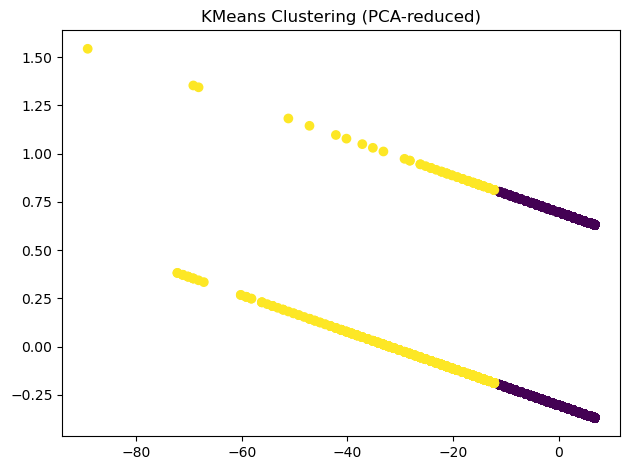

In [101]:
# Clustering: KMeans on numeric features + PCA for visualization
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select features for clustering: release year and encoded type
X = netflix[['release_year', 'type_encoded']]

# Reduce data to 2 dimensions for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Apply KMeans clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Plot the clusters on a 2D scatter plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title("KMeans Clustering (PCA-reduced)")
plt.tight_layout()
plt.savefig('KMeans_Clustering_PCA.png')  # Save scatter plot as image
plt.show()
plt.close()


### Save Cleaned Netflix Dataset

This code checks whether the `netflix` DataFrame exists and, if it does, saves it as a cleaned CSV file. The file is stored without the index column, and a confirmation message is printed showing the path where the cleaned dataset has been saved.

In [79]:
# Check if the 'netflix' DataFrame exists
if 'netflix' in globals():
    # Define the file path to save the cleaned dataset
    cleaned_path = 'netflix_cleaned_for_project.csv'
    
    # Save the DataFrame to a CSV file without the index column
    netflix.to_csv(cleaned_path, index=False)
    
    # Print confirmation message with the saved file path
    print('Saved cleaned dataset to', cleaned_path)


Saved cleaned dataset to netflix_cleaned_for_project.csv


### Conclusion

The Netflix EDA demonstrates how structured analysis of a public dataset can uncover meaningful patterns in content production and quality.
While numeric predictors alone don’t fully explain viewer ratings, combined statistical, machine learning, and clustering approaches reveal content archetypes that can inform both creative and marketing strategies.

This project meets the **DSC530 - Data Exploration and Analysis Final Project** requirements by integrating:

 - Data cleaning and preparation
 - Univariate + bivariate EDA
 - Statistical tests (t-test)
 - Regression and classification modeling
 - Clustering and dimensionality reduction
 - A comprehensive narrative and recommendation framework